# We can test the performance on the simulated data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee
from scipy.optimize import minimize
from scipy.stats import norm
import celerite2
from celerite2 import terms
from prettytable import PrettyTable
import sys
from pathlib import Path
from IPython.display import display as ipy_display

sys.path.append(str(Path('../..').resolve()))
from helpers.df_ops import prepare_df, split_df, clean_df, downsample_min_gap
from helpers.priors import find_classify_signals, get_priors
from helpers.gpr import set_params, NLL
from helpers.MCMC import lnPost_gp, plot_trace
from helpers.eval import check_constant
from helpers.pipeline import run_star, results_to_df


In [19]:
from pathlib import Path
import numpy as np

# Get the saved params of the simulated stars
sim_root = Path('../../Data/simulated')
params = np.load(sim_root / 'star_params.npz', allow_pickle=True)

star_labels = params['labels']

# Same 3 G-type stars across all folders for consistency
num_of_stars = 3
g_indices = np.where(star_labels == 'G')[0][:num_of_stars] 

# Or all stars
# g_indices = np.arange(len(star_labels))

# The stars are sampled into folders grouped by cadence. These folders are found here.
rate_folders = sorted([f for f in sim_root.iterdir() if f.is_dir()], key=lambda f: float(f.name.rstrip('d')))

dfs_by_rate = {} # {sampling_rate_str: df_sim}

for folder in rate_folders:
    rate_str = folder.name # '1.0d'
    rate_days = float(rate_str.rstrip('d')) 
    print(f"\n=== Sampling rate: {rate_str} ===")

    results = []
    for i in g_indices: # Loop through the stars being considered
        stype = star_labels[i]
        fpath = folder / f'sim{i:04d}_{stype}_caii.txt'
        star_name = f'sim{i:04d}_{stype}'
        print(f'  {star_name}  (P_cyc={params["P_cycs"][i]:.1f} yr, P_rot={params["P_rots"][i]:.1f} d)')
        result = run_star(
            datapath=str(fpath),
            star_name=star_name,
            star_type=stype,
            add_prefix=False,
            n_target_windows=5,
            verbose=True,
        )
        results.append(result)

    df = results_to_df(results)
    df['sampling_rate_days'] = rate_days
    dfs_by_rate[rate_str] = df

df_sim_all = pd.concat(dfs_by_rate.values(), ignore_index=True)
print(f"\nDone. {len(dfs_by_rate)} sampling rates, {len(df_sim_all)} total rows.")
df_sim_all.head()



=== Sampling rate: 1.0d ===
  sim0041_G  (P_cyc=5.4 yr, P_rot=20.0 d)
sim0041_G: selected 2sm (CRPS=7.1398)


c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


sim0041_G: selected 3sml (CRPS=7.6644)


c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


sim0041_G: selected 3sml (CRPS=7.5807)


...

c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


sim0041_G: selected 2sm (CRPS=8.6192)


c:\Users\Joey\Desktop\Cambridge\Work\Thesis\VenvThesis\lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]



=== Sampling rate: 60.3d ===
  sim0041_G  (P_cyc=5.4 yr, P_rot=20.0 d)

=== Sampling rate: 70.2d ===
  sim0041_G  (P_cyc=5.4 yr, P_rot=20.0 d)

=== Sampling rate: 80.1d ===
  sim0041_G  (P_cyc=5.4 yr, P_rot=20.0 d)

=== Sampling rate: 90.0d ===
  sim0041_G  (P_cyc=5.4 yr, P_rot=20.0 d)

Done. 10 sampling rates, 327 total rows.


,star,n_obs,span_years,split_idx,best_combo,rho_mid_years,Q_mid,n_cycles_obs,is_const,aleatoric_frac_at_t0,...,truth_med,truth_lb,truth_ub,error,abs_error,in_68,in_95,gpr_width_68,truth_width,sampling_rate_days
0,sim0041_G,1801.0,29.997262,0.0,2sm,5.428067,5.0,5.526325,True,0.997109,...,1994.073406,1994.073406,1994.073406,0.007863,0.007863,False,False,0.000000,0.000000,1.0
1,sim0041_G,1801.0,29.997262,0.0,2sm,5.428067,5.0,5.526325,True,0.997109,...,1994.433553,1994.433553,1994.463565,-0.133256,0.133256,False,False,0.027379,0.030012,1.0
2,sim0041_G,1801.0,29.997262,0.0,2sm,5.428067,5.0,5.526325,True,0.997109,...,1994.433553,1994.433553,1994.463565,-0.133256,0.133256,False,False,0.027379,0.030012,1.0
3,sim0041_G,1801.0,29.997262,0.0,2sm,5.428067,5.0,5.526325,True,0.997109,...,1994.433553,1994.433553,1994.463565,-0.133256,0.133256,False,False,0.027379,0.030012,1.0
4,sim0041_G,1801.0,29.997262,0.0,2sm,5.428067,5.0,5.526325,True,0.997109,...,1994.433553,1994.433553,1994.463565,-0.133256,0.133256,False,False,0.027379,0.030012,1.0


In [ ]:
# Uncomment if you want to save this!!!
# There is already a file with quite a long run. DO NOT OVERWRITE IT LIGHTLY!

# df_sim_all.to_csv("df_sim_all_test.csv")

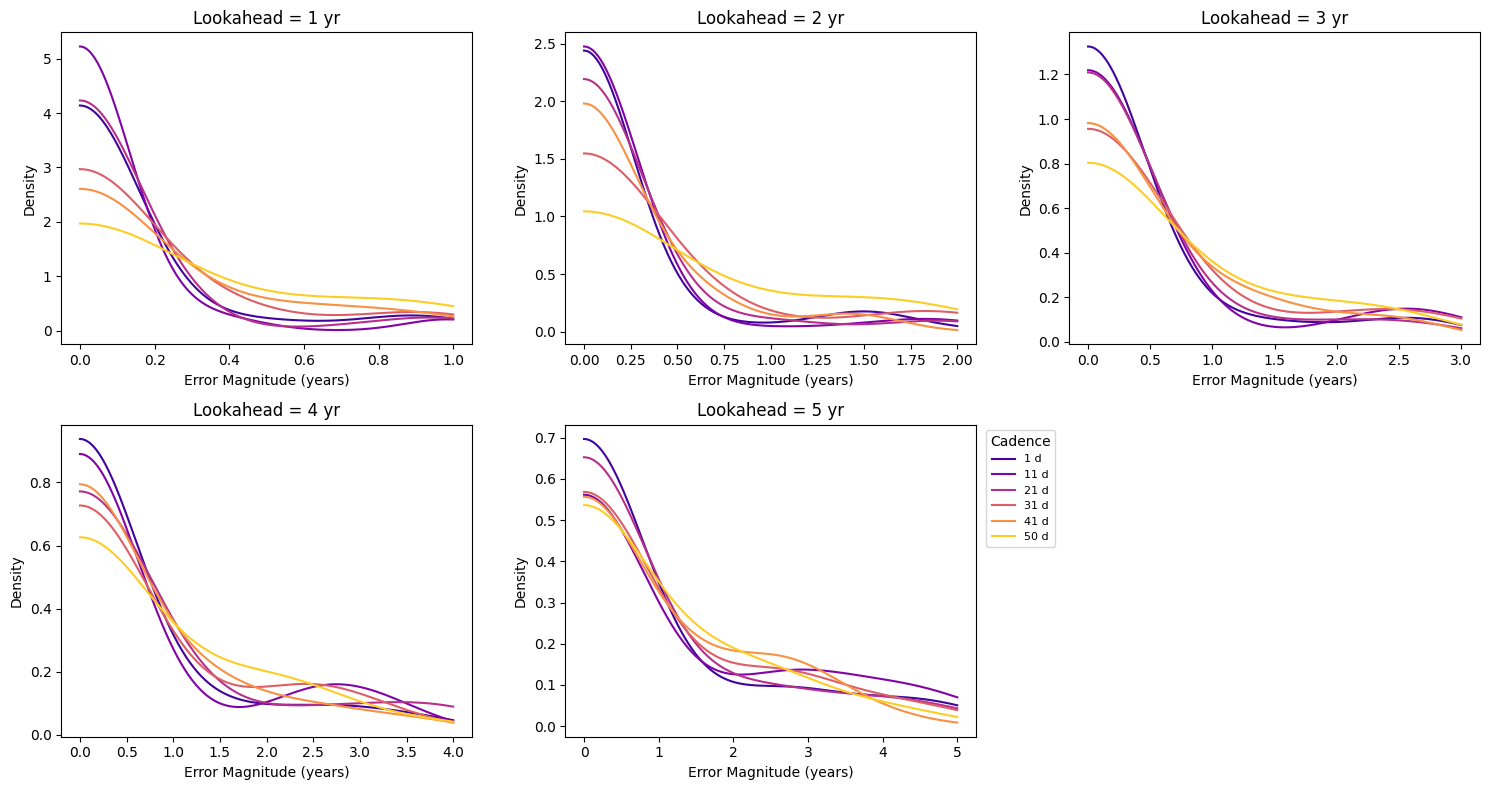

In [20]:
df = pd.read_csv("../../Results/simulated/all_rates.csv")

from scipy.stats import gaussian_kde

max_years = 5

# Get the first max_years of lookaheads
integer_lookaheads = sorted(df[(df['lookahead_years'] % 1 == 0) & (df['lookahead_years'] <= max_years)]['lookahead_years'].unique())
sampling_rates_sorted = sorted(df['sampling_rate_days'].unique())

# Defining the plotting grid
n_la = len(integer_lookaheads)
ncols = 3
nrows = int(np.ceil(n_la / ncols))

# Defining the colour scale for each 
rate_colours = {r: c for r, c in zip(sampling_rates_sorted, plt.cm.plasma(np.linspace(0.1, 0.9, len(sampling_rates_sorted))))}

# Create axes
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=False)
axes = axes.flatten()

# Loop through lookaheads
for ax_idx, la in enumerate(integer_lookaheads):
    ax = axes[ax_idx]
    # Loop through the sampling rates to plot for it
    for rate in sampling_rates_sorted:
        d = df[(df['lookahead_years'] == la) & (df['sampling_rate_days'] == rate)]['error'].dropna() # Drop errors
        xs = np.linspace(0, la, 300)
        kde_vals = gaussian_kde(d)(xs) + gaussian_kde(d)(-xs) # Absolute error
        kde_vals /= np.trapezoid(kde_vals, xs) # Normalise to proper PDF
        ax.plot(xs, kde_vals, color=rate_colours[rate], lw=1.5, label=f'{rate:.0f} d')

    ax.set_title(f'Lookahead = {int(la)} yr')
    ax.set_xlabel('Error Magnitude (years)')
    ax.set_ylabel('Density')

# If there are too many grid axes
for ax in axes[n_la:]:
    ax.set_visible(False)

axes[n_la - 1].legend(title='Cadence', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

fig.tight_layout()
fig.savefig(r"../../Report/Figures/CadenceAnalysis.png")
plt.show()


- Turn this into a neat little function.

In [ ]:
def plot_cadence_analysis(df, max_lookahead: int = 5, savefig = None):
    # Get the first max_years of lookaheads
    integer_lookaheads = sorted(df[(df['lookahead_years'] % 1 == 0) & (df['lookahead_years'] <= max_years)]['lookahead_years'].unique())
    sampling_rates_sorted = sorted(df['sampling_rate_days'].unique())

    # Defining the plotting grid
    n_la = len(integer_lookaheads)
    ncols = 3
    nrows = int(np.ceil(n_la / ncols))

    # Defining the colour scale for each 
    rate_colours = {r: c for r, c in zip(sampling_rates_sorted, plt.cm.plasma(np.linspace(0.1, 0.9, len(sampling_rates_sorted))))}

    # Create axes
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=False)
    axes = axes.flatten()

    # Loop through lookaheads
    for ax_idx, la in enumerate(integer_lookaheads):
        ax = axes[ax_idx]
        # Loop through the sampling rates to plot for it
        for rate in sampling_rates_sorted:
            d = df[(df['lookahead_years'] == la) & (df['sampling_rate_days'] == rate)]['error'].dropna() # Drop errors
            xs = np.linspace(0, la, 300)
            kde_vals = gaussian_kde(d)(xs) + gaussian_kde(d)(-xs) # Absolute error
            kde_vals /= np.trapezoid(kde_vals, xs) # Normalise to proper PDF
            ax.plot(xs, kde_vals, color=rate_colours[rate], lw=1.5, label=f'{rate:.0f} d')

        ax.set_title(f'Lookahead = {int(la)} yr')
        ax.set_xlabel('Error Magnitude (years)')
        ax.set_ylabel('Density')

    # If there are too many grid axes
    for ax in axes[n_la:]:
        ax.set_visible(False)

    axes[n_la - 1].legend(title='Cadence', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

    fig.tight_layout()
    if savefig:
        fig.savefig(savefig)
    plt.show()


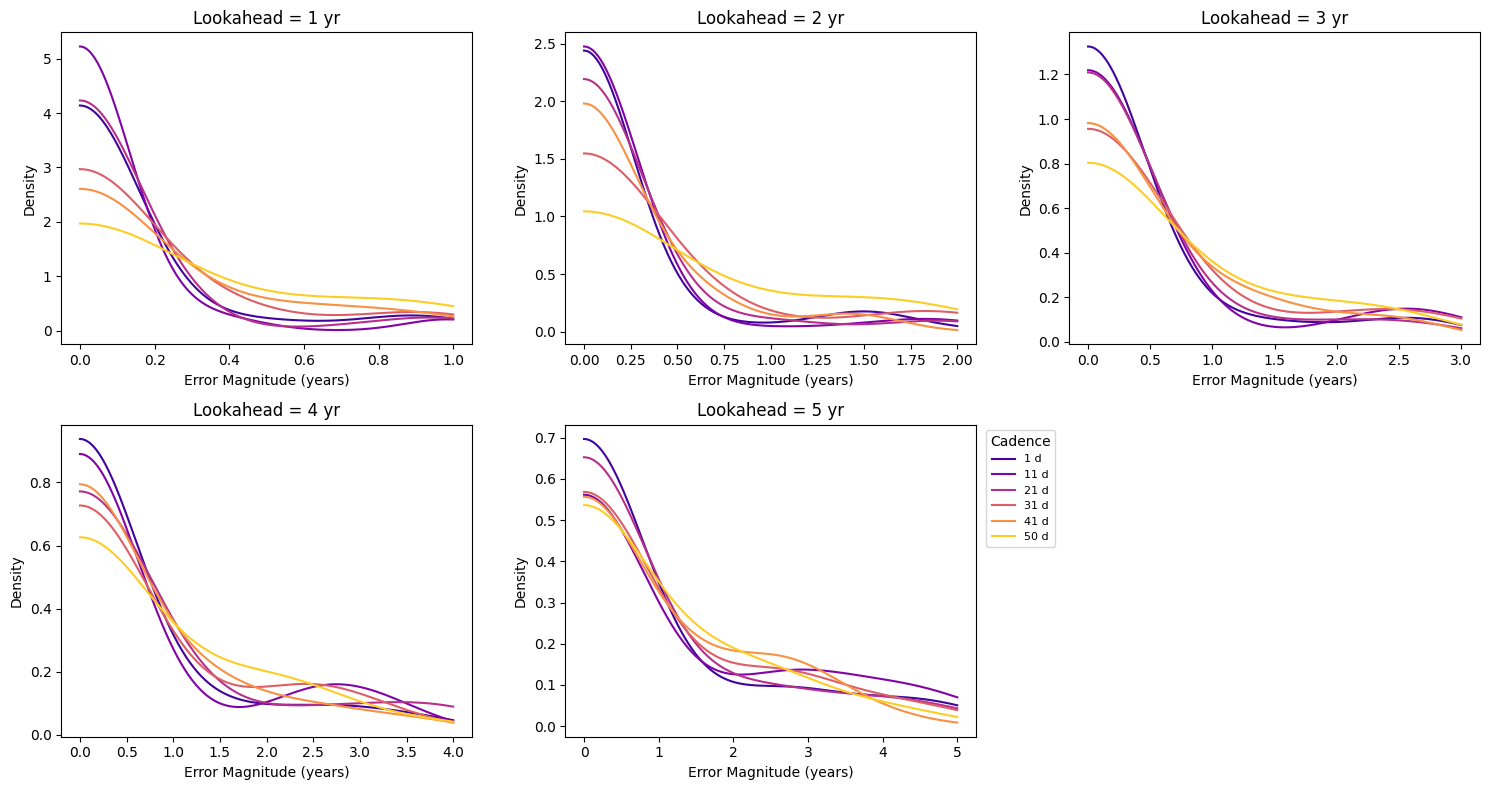

In [ ]:
plot_cadence_analysis(df)